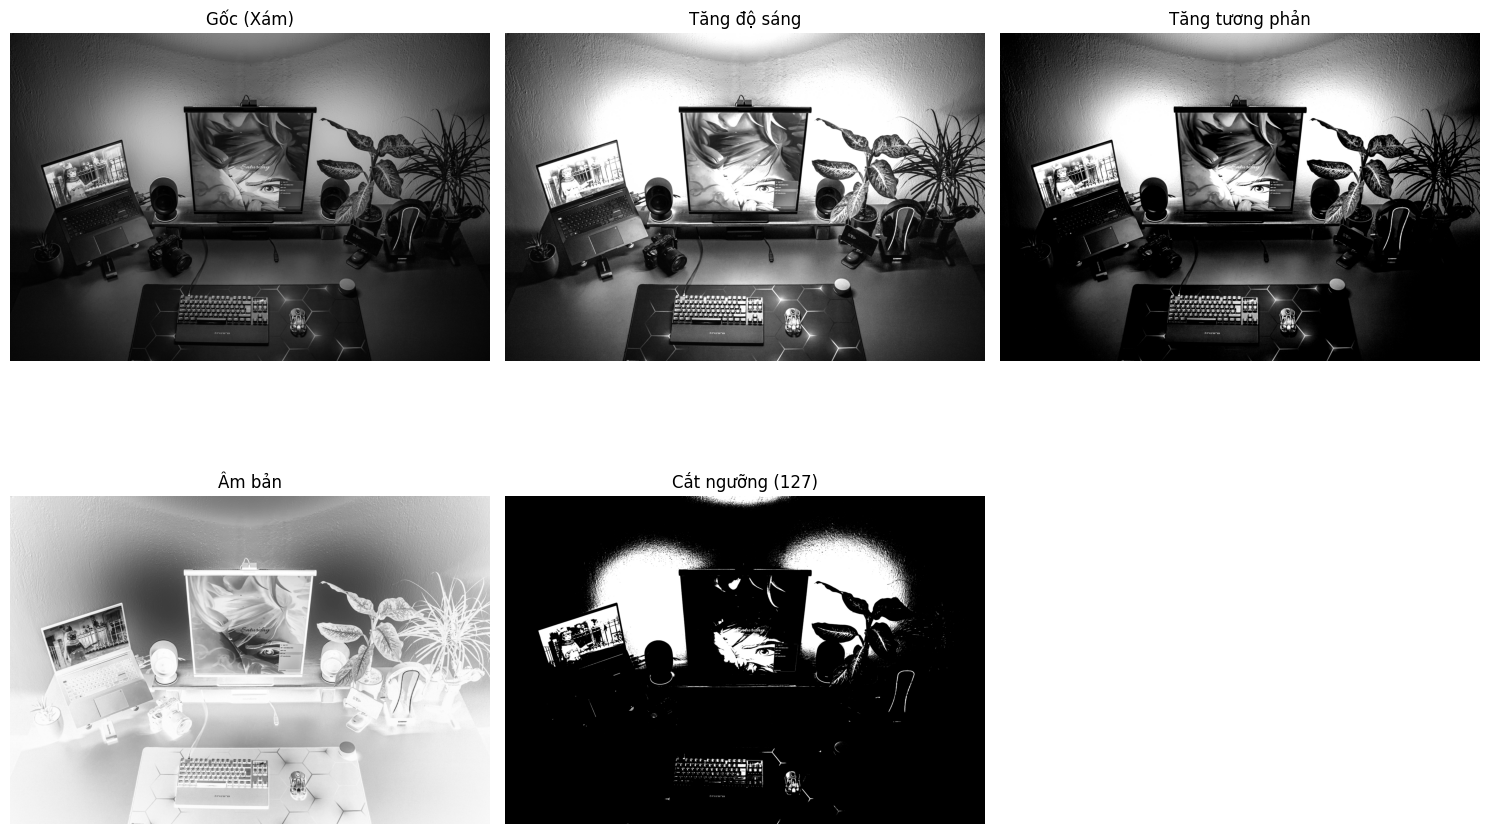

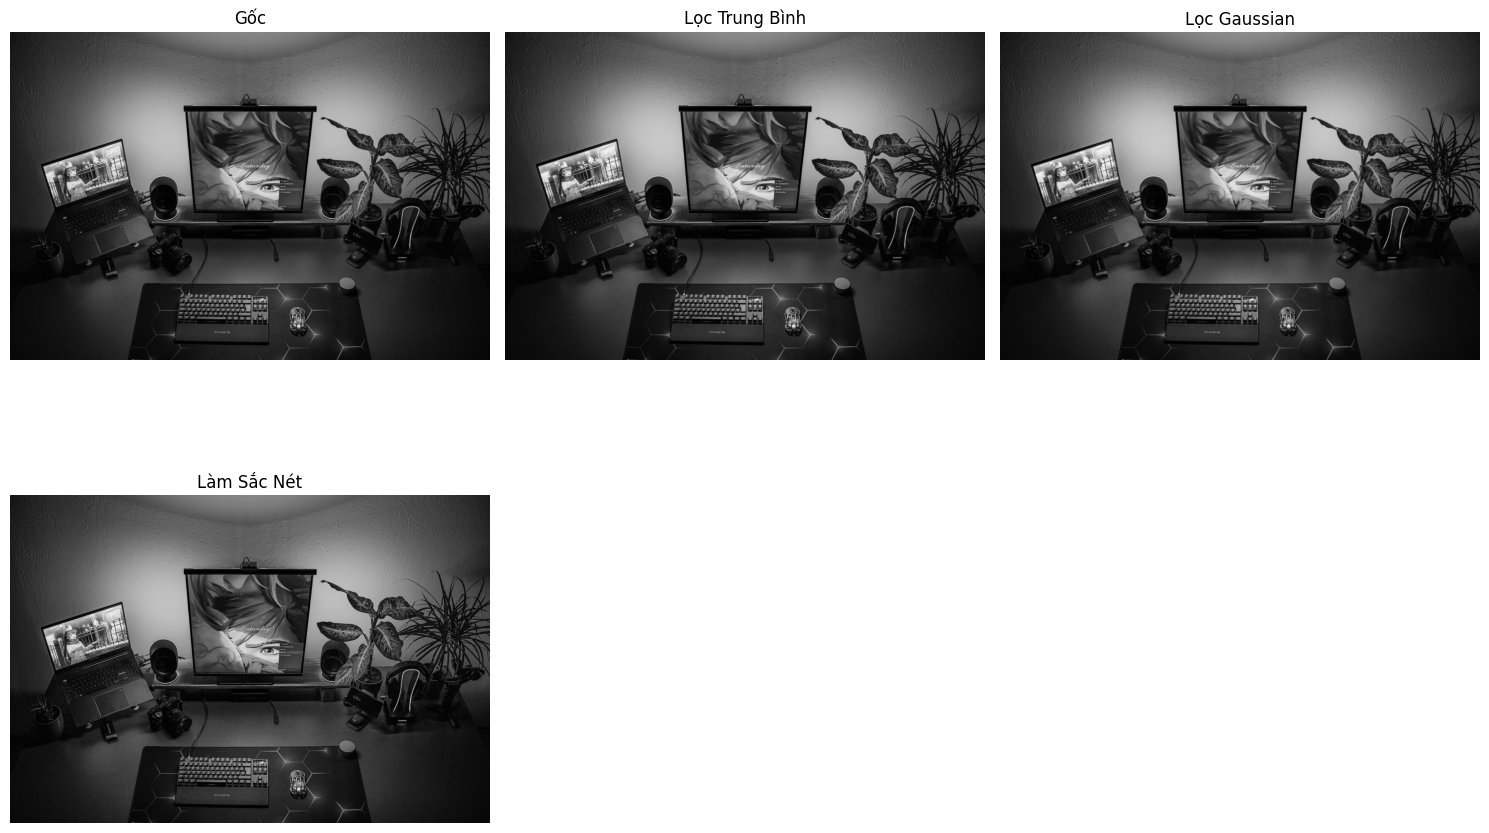

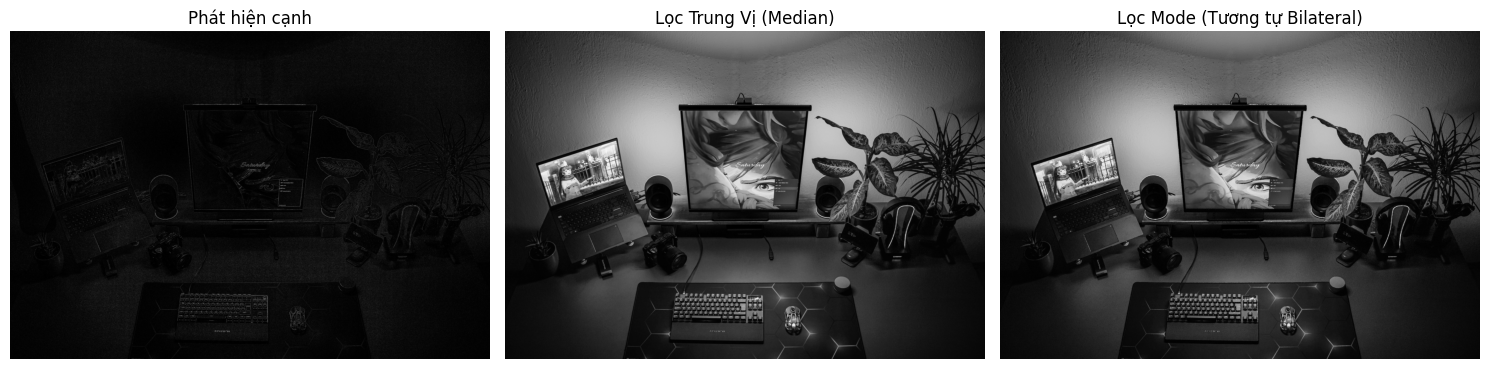

In [1]:
from PIL import Image, ImageOps, ImageEnhance, ImageFilter
import matplotlib.pyplot as plt
import numpy as np
# Hiển thị ảnh và tiêu đề ảnh
def show_pil_images(images, titles, columns=3):
    rows = (len(images) + columns - 1) // columns
    plt.figure(figsize=(15, 5 * rows))
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(rows, columns, i + 1)
        plt.imshow(img, cmap='gray' if img.mode == 'L' else None)
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Input image 
img_orig = Image.open('./assets/input.jpg')
# Chuyển ảnh sang xám
img_gray = img_orig.convert('L') 
# 1. Thay đổi độ sáng
enhancer_bright = ImageEnhance.Brightness(img_gray)
brightness_up = enhancer_bright.enhance(2)

# 2. Thay đổi độ tương phản
enhancer_contrast = ImageEnhance.Contrast(img_gray)
contrast_up = enhancer_contrast.enhance(2)

# 3. Biến đổi âm bản
negative_img = ImageOps.invert(img_gray)

# 4. Cắt ngưỡng (Thresholding)
thresh_img = img_gray.point(lambda p: 255 if p > 127 else 0, mode='1')

show_pil_images(
    [img_gray, brightness_up, contrast_up, negative_img, thresh_img],
    ['Gốc (Xám)', 'Tăng độ sáng', 'Tăng tương phản', 'Âm bản', 'Cắt ngưỡng (127)']
)
# 1. Lọc trung bình (Box Blur)
blur_avg = img_gray.filter(ImageFilter.BoxBlur(2)) 

# 2. Lọc Gaussian
blur_gaussian = img_gray.filter(ImageFilter.GaussianBlur(radius=2))

# 3. Làm sắc nét (Sharpen)
sharpen_img = img_gray.filter(ImageFilter.SHARPEN)

# Tự thiết kế Kernel 
custom_kernel = ImageFilter.Kernel((3, 3), [-1, -1, -1, -1, 9, -1, -1, -1, -1])
sharpen_custom = img_gray.filter(custom_kernel)

show_pil_images(
    [img_gray, blur_avg, blur_gaussian, sharpen_custom],
    ['Gốc', 'Lọc Trung Bình', 'Lọc Gaussian', 'Làm Sắc Nét']
)
# 1. Phát hiện cạnh (FIND_EDGES)
edges = img_gray.filter(ImageFilter.FIND_EDGES)

# 2. Lọc phi tuyến tính: Median Filter (Cực tốt để khử nhiễu)
median_blur = img_gray.filter(ImageFilter.MedianFilter(size=7))

mode_filter = img_gray.filter(ImageFilter.ModeFilter(size=7))

show_pil_images(
    [edges, median_blur, mode_filter],
    ['Phát hiện cạnh', 'Lọc Trung Vị (Median)', 'Lọc Mode (Tương tự Bilateral)']
)